In [8]:
 !sudo apt install unzip # unzip 이 없는 경우
 !mkdir -p ~/work/mpii
 !cd ~/work/mpii

 !wget https://datasets.d2.mpi-inf.mpg.de/andriluka14cvpr/mpii_human_pose_v1.tar.gz -P ~/work/mpii
 !wget https://datasets.d2.mpi-inf.mpg.de/andriluka14cvpr/mpii_human_pose_v1_u12_2.zip -P ~/work/mpii
 !tar -xf ~/work/mpii/mpii_human_pose_v1.tar.gz -C ~/work/mpii
 !unzip -q ~/work/mpii/mpii_human_pose_v1_u12_2.zip -d ~/work/mpii

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unzip is already the newest version (6.0-28ubuntu4.1).
0 upgraded, 0 newly installed, 0 to remove and 0 not upgraded.
--2026-07-09 02:35:31--  https://datasets.d2.mpi-inf.mpg.de/andriluka14cvpr/mpii_human_pose_v1.tar.gz
Resolving datasets.d2.mpi-inf.mpg.de (datasets.d2.mpi-inf.mpg.de)... 139.19.206.177
Connecting to datasets.d2.mpi-inf.mpg.de (datasets.d2.mpi-inf.mpg.de)|139.19.206.177|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12088943206 (11G) [application/x-gzip]
Saving to: ‘/home/jovyan/work/mpii/mpii_human_pose_v1.tar.gz’

mpii_human_pose_v1. 100%[===================>]  11.26G  5.81MB/s    in 40m 37s 

2026-07-09 03:16:09 (4.73 MB/s) - ‘/home/jovyan/work/mpii/mpii_human_pose_v1.tar.gz’ saved [12088943206/12088943206]

--2026-07-09 03:16:09--  https://datasets.d2.mpi-inf.mpg.de/andriluka14cvpr/mpii_human_pose_v1_u12_2.zip
Resolving datasets.d2.mpi-inf.mpg.

In [9]:
 !cd ~/work/mpii/mpii_human_pose_v1_u12_2
 !wget https://d3s0tskafalll9.cloudfront.net/media/documents/train.json
 !wget https://d3s0tskafalll9.cloudfront.net/media/documents/validation.json
 !mv train.json ~/work/mpii/mpii_human_pose_v1_u12_2/
 !mv validation.json ~/work/mpii/mpii_human_pose_v1_u12_2/

--2026-07-09 03:19:31--  https://d3s0tskafalll9.cloudfront.net/media/documents/train.json
Resolving d3s0tskafalll9.cloudfront.net (d3s0tskafalll9.cloudfront.net)... 18.65.14.93, 18.65.14.120, 18.65.14.110, ...
Connecting to d3s0tskafalll9.cloudfront.net (d3s0tskafalll9.cloudfront.net)|18.65.14.93|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 31043010 (30M) [application/json]
Saving to: ‘train.json’

train.json          100%[===================>]  29.60M  95.6MB/s    in 0.3s    

2026-07-09 03:19:31 (95.6 MB/s) - ‘train.json’ saved [31043010/31043010]

--2026-07-09 03:19:31--  https://d3s0tskafalll9.cloudfront.net/media/documents/validation.json
Resolving d3s0tskafalll9.cloudfront.net (d3s0tskafalll9.cloudfront.net)... 65.9.180.12, 65.9.180.44, 65.9.180.5, ...
Connecting to d3s0tskafalll9.cloudfront.net (d3s0tskafalll9.cloudfront.net)|65.9.180.12|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4127396 (3.9M) [application/json]
Saving

In [10]:
 !wget https://d3s0tskafalll9.cloudfront.net/media/documents/mpii_gtuV0hd.zip -O mpii.zip
 !unzip ~/mpii.zip -d ~/work/mpii

--2026-07-09 03:20:07--  https://d3s0tskafalll9.cloudfront.net/media/documents/mpii_gtuV0hd.zip
Resolving d3s0tskafalll9.cloudfront.net (d3s0tskafalll9.cloudfront.net)... 18.65.14.93, 18.65.14.120, 18.65.14.110, ...
Connecting to d3s0tskafalll9.cloudfront.net (d3s0tskafalll9.cloudfront.net)|18.65.14.93|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12488 (12K) [application/zip]
Saving to: ‘mpii.zip’

mpii.zip            100%[===================>]  12.20K  --.-KB/s    in 0s      

2026-07-09 03:20:08 (837 MB/s) - ‘mpii.zip’ saved [12488/12488]

unzip:  cannot find or open /home/jovyan/mpii.zip, /home/jovyan/mpii.zip.zip or /home/jovyan/mpii.zip.ZIP.


In [11]:
! pip install ray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.2/74.2 MB 49.8 MB/s eta 0:00:0000:0100:01


In [12]:
import os

MPII_DIR = os.path.join(os.getenv("HOME"), "work", "mpii")

tar_path = os.path.join(MPII_DIR, "mpii_human_pose_v1.tar.gz")
if os.path.exists(tar_path):
    size = os.path.getsize(tar_path)
    print(f"tar.gz 파일 크기: {size} bytes ({size / 1e9:.2f} GB)")
else:
    print("tar.gz 파일이 아직 없습니다.")

image_dir = os.path.join(MPII_DIR, "images")
if os.path.exists(image_dir):
    print("images 폴더 내 파일 개수:", len(os.listdir(image_dir)))
else:
    print("images 폴더가 아직 없습니다.")

tar.gz 파일 크기: 12088943206 bytes (12.09 GB)
images 폴더 내 파일 개수: 24984


In [13]:
# 주의! ray를 pytorch보다 먼저 import하면 오류가 발생할 수 있습니다
import io, json, os, math

import torch
import torch.nn as nn
import torch.nn.functional as F

import ray

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# 프로젝트 경로 설정
PROJECT_PATH = os.path.join(os.getenv("HOME"), 'work/mpii')
IMAGE_PATH = os.path.join(PROJECT_PATH, 'images')
MODEL_PATH = os.path.join(PROJECT_PATH, 'models')
PT_RECORD_PATH = os.path.join(PROJECT_PATH, 'ptrecords_mpii')
TRAIN_JSON = os.path.join(PROJECT_PATH, 'mpii_human_pose_v1_u12_2', 'train.json')
VALID_JSON = os.path.join(PROJECT_PATH, 'mpii_human_pose_v1_u12_2', 'validation.json')

print('슝=3')

슝=3


In [14]:
with open(TRAIN_JSON) as train_json:
    train_annos = json.load(train_json)
    json_formatted_str = json.dumps(train_annos[0], indent=2)
    print(json_formatted_str)

{
  "joints_vis": [
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1
  ],
  "joints": [
    [
      620.0,
      394.0
    ],
    [
      616.0,
      269.0
    ],
    [
      573.0,
      185.0
    ],
    [
      647.0,
      188.0
    ],
    [
      661.0,
      221.0
    ],
    [
      656.0,
      231.0
    ],
    [
      610.0,
      187.0
    ],
    [
      647.0,
      176.0
    ],
    [
      637.0201,
      189.8183
    ],
    [
      695.9799,
      108.1817
    ],
    [
      606.0,
      217.0
    ],
    [
      553.0,
      161.0
    ],
    [
      601.0,
      167.0
    ],
    [
      692.0,
      185.0
    ],
    [
      693.0,
      240.0
    ],
    [
      688.0,
      313.0
    ]
  ],
  "image": "015601864.jpg",
  "scale": 3.021046,
  "center": [
    594.0,
    257.0
  ]
}


In [15]:
def parse_one_annotation(anno, image_dir):
    filename = anno['image']
    joints = anno['joints']
    joints_visibility = anno['joints_vis']
    annotation = {
        'filename': filename,
        'filepath': os.path.join(image_dir, filename),
        'joints_visibility': joints_visibility,
        'joints': joints,
        'center': anno['center'],
        'scale' : anno['scale']
    }
    return annotation

print('슝=3')

슝=3


In [16]:
with open(TRAIN_JSON) as train_json:
    train_annos = json.load(train_json)
    test = parse_one_annotation(train_annos[0], IMAGE_PATH)
    print(test)

{'filename': '015601864.jpg', 'filepath': '/home/jovyan/work/mpii/images/015601864.jpg', 'joints_visibility': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'joints': [[620.0, 394.0], [616.0, 269.0], [573.0, 185.0], [647.0, 188.0], [661.0, 221.0], [656.0, 231.0], [610.0, 187.0], [647.0, 176.0], [637.0201, 189.8183], [695.9799, 108.1817], [606.0, 217.0], [553.0, 161.0], [601.0, 167.0], [692.0, 185.0], [693.0, 240.0], [688.0, 313.0]], 'center': [594.0, 257.0], 'scale': 3.021046}


In [17]:
def generate_ptexample(anno):
    filename = anno['filename']
    filepath = anno['filepath']

    # 이미지 파일 읽기
    with open(filepath, 'rb') as image_file:
        content = image_file.read()

    image = Image.open(filepath)
    # JPEG 형식 및 RGB 모드가 아니면 변환
    if image.format != 'JPEG' or image.mode != 'RGB':
        image_rgb = image.convert('RGB')
        with io.BytesIO() as output:
            image_rgb.save(output, format="JPEG", quality=95)
            content = output.getvalue()

    width, height = image.size
    depth = 3

    c_x = int(anno['center'][0])
    c_y = int(anno['center'][1])
    scale = anno['scale']

    x = [int(joint[0]) if joint[0] >= 0 else int(joint[0])
         for joint in anno['joints']]
    y = [int(joint[1]) if joint[1] >= 0 else int(joint[0])
         for joint in anno['joints']]

    v = [0 if joint_v == 0 else 2 for joint_v in anno['joints_visibility']]

    feature = {
        'image/height': height,
        'image/width': width,
        'image/depth': depth,
        'image/object/parts/x': x,
        'image/object/parts/y': y,
        'image/object/center/x': c_x,
        'image/object/center/y': c_y,
        'image/object/scale': scale,
        'image/object/parts/v': v,
        'image/encoded': content,
        'image/filename': filename.encode()  # bytes로 저장
    }

    return feature

print('슝=3')

슝=3


In [18]:
def chunkify(l, n):
    size = len(l) // n
    start = 0
    results = []
    for i in range(n):
        results.append(l[start:start + size])
        start += size
    return results

print('슝=3')

슝=3


In [19]:
def generate_ptexample(anno):
    filename = anno['filename']
    filepath = anno['filepath']

    # 이미지 파일 읽기
    with open(filepath, 'rb') as image_file:
        content = image_file.read()

    image = Image.open(filepath)
    # JPEG 형식 및 RGB 모드가 아니면 변환
    if image.format != 'JPEG' or image.mode != 'RGB':
        image_rgb = image.convert('RGB')
        with io.BytesIO() as output:
            image_rgb.save(output, format="JPEG", quality=95)
            content = output.getvalue()

    width, height = image.size
    depth = 3

    c_x = int(anno['center'][0])
    c_y = int(anno['center'][1])
    scale = anno['scale']

    x = [int(joint[0]) if joint[0] >= 0 else int(joint[0])
         for joint in anno['joints']]
    y = [int(joint[1]) if joint[1] >= 0 else int(joint[0])
         for joint in anno['joints']]

    v = [0 if joint_v == 0 else 2 for joint_v in anno['joints_visibility']]

    feature = {
        'image/height': height,
        'image/width': width,
        'image/depth': depth,
        'image/object/parts/x': x,
        'image/object/parts/y': y,
        'image/object/center/x': c_x,
        'image/object/center/y': c_y,
        'image/object/scale': scale,
        'image/object/parts/v': v,
        'image/encoded': content,
        'image/filename': filename.encode()  # bytes로 저장
    }

    return feature

print('슝=3')

슝=3


In [20]:
def chunkify(l, n):
    size = len(l) // n
    start = 0
    results = []
    for i in range(n):
        results.append(l[start:start + size])
        start += size
    return results

print('슝=3')

슝=3


In [21]:
test_chunks = chunkify([0] * 1000, 64)
print(test_chunks)
print(len(test_chunks))
print(len(test_chunks[0]))

[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0,

In [22]:
import pickle

@ray.remote
def build_single_ptrecord(chunk, path):
    print('start to build ptrecord for ' + path)

    with open(path, 'wb') as writer:
        for anno in chunk:
            ptexample = generate_ptexample(anno)
            pickle.dump(ptexample, writer)

    print('finished building ptrecord for ' + path)

print('슝=3')

슝=3


In [23]:
def build_pt_records(annotations, total_shards, split):
    chunks = chunkify(annotations, total_shards)
    futures = [
        build_single_ptrecord.remote(
            chunk, '{}/{}_{}_of_{}.ptrecords'.format(
                PT_RECORD_PATH,
                split,
                str(i + 1).zfill(4),
                str(total_shards).zfill(4),
            )
        ) for i, chunk in enumerate(chunks)
    ]
    ray.get(futures)

print('슝=3')

슝=3


In [24]:
from torch.utils.data import Dataset

class MPIIDataset(Dataset):
    def __init__(self, annotation_file, image_dir, transform=None):
        self.image_dir = image_dir
        self.transform = transform

        # JSON 파일을 읽어 annotations 리스트 생성
        with open(annotation_file, 'r') as f:
            annotations = json.load(f)

        # 각 annotation을 파싱하여 리스트에 저장
        self.annotations = [parse_one_annotation(anno, image_dir) for anno in annotations]

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        anno = self.annotations[idx]
        # 이미지 파일 경로로부터 이미지를 로드 (RGB 모드로 변환)
        image = Image.open(anno['filepath']).convert('RGB')

        # transform이 있으면 적용
        if self.transform:
            image, heatmaps = self.transform({'image': image, 'annotation': anno})
            return image, heatmaps
        else:
            # transform이 없으면 원본 이미지와 annotation dict 반환
            return image, anno

In [26]:
os.makedirs(os.path.join(PT_RECORD_PATH, 'train'), exist_ok=True)
os.makedirs(os.path.join(PT_RECORD_PATH, 'val'), exist_ok=True)

In [27]:
%%time
num_train_shards = 64
num_val_shards = 8

ray.init()

print('Start to parse annotations.')
if not os.path.exists(PT_RECORD_PATH):
    os.makedirs(PT_RECORD_PATH)

with open(TRAIN_JSON) as train_json:
    train_annos = json.load(train_json)
    train_annotations = [
        parse_one_annotation(anno, IMAGE_PATH)
        for anno in train_annos
    ]
    print('First train annotation: ', train_annotations[0])

with open(VALID_JSON) as val_json:
    val_annos = json.load(val_json)
    val_annotations = [
        parse_one_annotation(anno, IMAGE_PATH)
        for anno in val_annos
    ]
    print('First val annotation: ', val_annotations[0])

print('Start to build PT Records.')
build_pt_records(train_annotations, num_train_shards, 'train')
build_pt_records(val_annotations, num_val_shards, 'val')

print('Successfully wrote {} annotations to PT Records.'.format(
    len(train_annotations) + len(val_annotations)))

2026-07-09 04:29:59,334	WARNING services.py:2248 -- WARNING: The object store is using /tmp/ray instead of /dev/shm because /dev/shm has only 67108864 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=4.86gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.
2026-07-09 04:30:01,518	INFO worker.py:2024 -- Started a local Ray instance.


Start to parse annotations.
First train annotation:  {'filename': '015601864.jpg', 'filepath': '/home/jovyan/work/mpii/images/015601864.jpg', 'joints_visibility': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'joints': [[620.0, 394.0], [616.0, 269.0], [573.0, 185.0], [647.0, 188.0], [661.0, 221.0], [656.0, 231.0], [610.0, 187.0], [647.0, 176.0], [637.0201, 189.8183], [695.9799, 108.1817], [606.0, 217.0], [553.0, 161.0], [601.0, 167.0], [692.0, 185.0], [693.0, 240.0], [688.0, 313.0]], 'center': [594.0, 257.0], 'scale': 3.021046}
First val annotation:  {'filename': '005808361.jpg', 'filepath': '/home/jovyan/work/mpii/images/005808361.jpg', 'joints_visibility': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'joints': [[804.0, 711.0], [816.0, 510.0], [908.0, 438.0], [1040.0, 454.0], [906.0, 528.0], [883.0, 707.0], [974.0, 446.0], [985.0, 253.0], [982.7591, 235.9694], [962.2409, 80.0306], [869.0, 214.0], [798.0, 340.0], [902.0, 253.0], [1067.0, 253.0], [1167.0, 353.0], [1142.0, 478.0

In [28]:
!pip install tfrecord

  Preparing metadata (setup.py) ... done
  DEPRECATION: Building 'tfrecord' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'tfrecord'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for tfrecord: filename=tfrecord-1.14.6-py3-none-any.whl size=14914 sha256=f05173e113116a8ce0a37a72841e6e1301bfd3f27fdb8592d76bf94907570bee
  Stored in directory: /home/jovyan/.cache/pip/wheels/bf/00/32/db9abfb84508d182806ca91e7391ca865d5037e585c088e8e6
Successfully built tfrecord
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [tfrecord]


In [29]:
from tfrecord.torch.dataset import TFRecordDataset

feature_description = {
    'image/height': 'int',
    'image/width': 'int',
    'image/depth': 'int',
    'image/object/parts/x': 'int',
    'image/object/parts/y': 'int',
    'image/object/parts/v': 'int',
    'image/object/center/x': 'int',
    'image/object/center/y': 'int',
    'image/object/scale': 'float',
    'image/encoded': 'byte',
    'image/filename': 'byte',
}

print('슝=3')

슝=3


In [30]:
import torch

def crop_roi(image, features, margin=0.2):
    img_height, img_width, img_depth = image.shape

    keypoint_x = torch.tensor(features['image/object/parts/x'], dtype=torch.int32)
    keypoint_y = torch.tensor(features['image/object/parts/y'], dtype=torch.int32)
    center_x = features['image/object/center/x']
    center_y = features['image/object/center/y']
    body_height = features['image/object/scale'] * 200.0

    # 유효한 keypoint (값이 0보다 큰 값)만 선택합니다.
    masked_keypoint_x = keypoint_x[keypoint_x > 0]
    masked_keypoint_y = keypoint_y[keypoint_y > 0]

    # 최소, 최대 값 계산 (유효한 keypoint가 하나 이상 있다고 가정)
    keypoint_xmin = masked_keypoint_x.min()
    keypoint_xmax = masked_keypoint_x.max()
    keypoint_ymin = masked_keypoint_y.min()
    keypoint_ymax = masked_keypoint_y.max()

    # margin을 적용하여 경계를 확장 (body_height * margin 값을 정수로 캐스팅)
    extra = int(body_height * margin)
    xmin = int(keypoint_xmin.item()) - extra
    xmax = int(keypoint_xmax.item()) + extra
    ymin = int(keypoint_ymin.item()) - extra
    ymax = int(keypoint_ymax.item()) + extra

    # 이미지 경계를 벗어나지 않도록 조정
    effective_xmin = xmin if xmin > 0 else 0
    effective_ymin = ymin if ymin > 0 else 0
    effective_xmax = xmax if xmax < img_width else img_width
    effective_ymax = ymax if ymax < img_height else img_height

    # 이미지 크기 재조정
    cropped_image = image[effective_ymin:effective_ymax, effective_xmin:effective_xmax, :]
    new_height, new_width, _ = cropped_image.shape

    # keypoint 좌표를 정규화 (0~1 범위)
    effective_keypoint_x = (keypoint_x.float() - effective_xmin) / new_width
    effective_keypoint_y = (keypoint_y.float() - effective_ymin) / new_height

    return cropped_image, effective_keypoint_x, effective_keypoint_y

print('슝=3')

슝=3


In [31]:
import torch

def generate_2d_gaussian(height, width, y0, x0, visibility=2, sigma=1, scale=12):
    # (height, width) 크기의 0으로 채워진 heatmap 생성
    heatmap = torch.zeros((height, width), dtype=torch.float32)

    xmin = x0 - 3 * sigma
    ymin = y0 - 3 * sigma
    xmax = x0 + 3 * sigma
    ymax = y0 + 3 * sigma

    # 범위가 이미지 내에 없거나, visibility가 0이면 heatmap 그대로 반환
    if xmin >= width or ymin >= height or xmax < 0 or ymax < 0 or visibility == 0:
        return heatmap

    size = int(6 * sigma + 1)
    grid_range = torch.arange(0, size, dtype=torch.float32)
    x_grid, y_grid = torch.meshgrid(grid_range, grid_range, indexing='xy')
    center_x = size // 2
    center_y = size // 2

    # 가우시안 patch 계산
    gaussian_patch = torch.exp(-(((x_grid - center_x)**2 + (y_grid - center_y)**2) / (sigma**2 * 2))) * scale

    # 이미지와 patch 간의 겹치는 영역 계산
    patch_xmin = max(0, -xmin)
    patch_ymin = max(0, -ymin)
    patch_xmax = min(xmax, width) - xmin
    patch_ymax = min(ymax, height) - ymin

    heatmap_xmin = max(0, xmin)
    heatmap_ymin = max(0, ymin)
    heatmap_xmax = min(xmax, width)
    heatmap_ymax = min(ymax, height)

    # 계산된 영역에 gaussian_patch 값을 할당
    heatmap[heatmap_ymin:heatmap_ymax, heatmap_xmin:heatmap_xmax] = \
        gaussian_patch[int(patch_ymin):int(patch_ymax), int(patch_xmin):int(patch_xmax)]

    return heatmap

def make_heatmaps(features, keypoint_x, keypoint_y, heatmap_shape):
    v = torch.tensor(features['image/object/parts/v'], dtype=torch.float32)
    x = torch.round(torch.tensor(keypoint_x, dtype=torch.float32) * heatmap_shape[0]).to(torch.int32)
    y = torch.round(torch.tensor(keypoint_y, dtype=torch.float32) * heatmap_shape[1]).to(torch.int32)

    num_heatmap = heatmap_shape[2]
    heatmaps_list = []
    for i in range(num_heatmap):
        # generate_2d_gaussian 함수 호출 시, height=heatmap_shape[1], width=heatmap_shape[0]
        gaussian = generate_2d_gaussian(
            heatmap_shape[1],
            heatmap_shape[0],
            int(y[i].item()),
            int(x[i].item()),
            visibility=int(v[i].item())
        )
        heatmaps_list.append(gaussian)

    # (num_heatmap, height, width) 텐서를 생성한 후, (height, width, num_heatmap)로 전치
    heatmaps = torch.stack(heatmaps_list, dim=0)
    heatmaps = heatmaps.permute(1, 2, 0)

    return heatmaps

print('슝=3')

슝=3


In [32]:
import torch
from PIL import Image
import io
import numpy as np

class Preprocessor(object):
    def __init__(self,
                 image_shape=(256, 256, 3),
                 heatmap_shape=(64, 64, 16),
                 is_train=False):
        self.is_train = is_train
        self.image_shape = image_shape      # (height, width, channels)
        self.heatmap_shape = heatmap_shape  # (height, width, num_heatmap)

    def __call__(self, example):
        features = self.parse_tfexample(example)
        # image 데이터를 다시 bytes로 디코딩 후 재로딩 (JPEG 형식)
        image = Image.open(io.BytesIO(features['image/encoded']))

        if self.is_train:
            # 0.1 ~ 0.3 사이의 random margin 생성
            random_margin = torch.empty(1).uniform_(0.1, 0.3).item()
            image, keypoint_x, keypoint_y = self.crop_roi(image, features, margin=random_margin)
            image = image.resize((self.image_shape[1], self.image_shape[0]))
        else:
            image, keypoint_x, keypoint_y = self.crop_roi(image, features)
            image = image.resize((self.image_shape[1], self.image_shape[0]))

        # 이미지 정규화: uint8 → [0,255] → [-1, 1]
        image_np = np.array(image).astype(np.float32)
        image_np = image_np / 127.5 - 1.0
        # 채널 우선순서로 변환: (H, W, C) -> (C, H, W)
        image_tensor = torch.from_numpy(image_np).permute(2, 0, 1)

        heatmaps = self.make_heatmaps(features, keypoint_x, keypoint_y, self.heatmap_shape)

        return image_tensor, heatmaps

    def parse_tfexample(self, example):
        """
        MPIIDataset에서 전달한 예제를 받아, Preprocessor가 처리할 수 있도록 features dict를 구성합니다.
        예제 형식: {'image': PIL.Image, 'annotation': anno}
        """
        annotation = example['annotation']
        # joints: list of [x, y]
        joints = annotation['joints']
        keypoint_x = [joint[0] for joint in joints]
        keypoint_y = [joint[1] for joint in joints]

        # joints_vis가 없으면 모든 관절이 가시적이라고 가정 (1)
        joints_vis = annotation.get('joints_vis', [1] * len(joints))

        features = {
            'image/encoded': self.image_to_bytes(example['image']),
            'image/object/parts/x': keypoint_x,
            'image/object/parts/y': keypoint_y,
            'image/object/parts/v': joints_vis,
            'image/object/center/x': annotation['center'][0],
            'image/object/center/y': annotation['center'][1],
            'image/object/scale': annotation['scale'],
        }
        return features

    def image_to_bytes(self, image):
        """
        PIL.Image 객체를 JPEG 인코딩된 bytes로 변환합니다.
        """
        buffer = io.BytesIO()
        image.save(buffer, format="JPEG")
        return buffer.getvalue()

    def crop_roi(self, image, features, margin=0.2):
        # image: PIL.Image, features: dict
        img_width, img_height = image.size  # PIL: (width, height)

        keypoint_x = torch.tensor(features['image/object/parts/x'], dtype=torch.int32)
        keypoint_y = torch.tensor(features['image/object/parts/y'], dtype=torch.int32)
        body_height = features['image/object/scale'] * 200.0

        # 유효한 keypoint (값 > 0)만 선택
        masked_keypoint_x = keypoint_x[keypoint_x > 0]
        masked_keypoint_y = keypoint_y[keypoint_y > 0]

        keypoint_xmin = int(masked_keypoint_x.min().item())
        keypoint_xmax = int(masked_keypoint_x.max().item())
        keypoint_ymin = int(masked_keypoint_y.min().item())
        keypoint_ymax = int(masked_keypoint_y.max().item())

        extra = int(body_height * margin)
        xmin = keypoint_xmin - extra
        xmax = keypoint_xmax + extra
        ymin = keypoint_ymin - extra
        ymax = keypoint_ymax + extra

        effective_xmin = max(xmin, 0)
        effective_ymin = max(ymin, 0)
        effective_xmax = min(xmax, img_width)
        effective_ymax = min(ymax, img_height)

        cropped_image = image.crop((effective_xmin, effective_ymin, effective_xmax, effective_ymax))

        new_width = effective_xmax - effective_xmin
        new_height = effective_ymax - effective_ymin

        effective_keypoint_x = (keypoint_x.float() - effective_xmin) / new_width
        effective_keypoint_y = (keypoint_y.float() - effective_ymin) / new_height

        return cropped_image, effective_keypoint_x, effective_keypoint_y

    def generate_2d_guassian(self, height, width, y0, x0, visibility=2, sigma=1, scale=12):
        heatmap = torch.zeros((height, width), dtype=torch.float32)

        xmin = x0 - 3 * sigma
        ymin = y0 - 3 * sigma
        xmax = x0 + 3 * sigma
        ymax = y0 + 3 * sigma

        if xmin >= width or ymin >= height or xmax < 0 or ymax < 0 or visibility == 0:
            return heatmap

        size = int(6 * sigma + 1)
        grid_range = torch.arange(0, size, dtype=torch.float32)
        x_grid, y_grid = torch.meshgrid(grid_range, grid_range, indexing='xy')
        center_x = size // 2
        center_y = size // 2

        gaussian_patch = torch.exp(-(((x_grid - center_x)**2 + (y_grid - center_y)**2) / (2 * sigma**2))) * scale

        patch_xmin = max(0, -xmin)
        patch_ymin = max(0, -ymin)
        patch_xmax = min(xmax, width) - xmin
        patch_ymax = min(ymax, height) - ymin

        heatmap_xmin = max(0, xmin)
        heatmap_ymin = max(0, ymin)
        heatmap_xmax = min(xmax, width)
        heatmap_ymax = min(ymax, height)

        heatmap[heatmap_ymin:heatmap_ymax, heatmap_xmin:heatmap_xmax] = \
            gaussian_patch[int(patch_ymin):int(patch_ymax), int(patch_xmin):int(patch_xmax)]

        return heatmap

    def make_heatmaps(self, features, keypoint_x, keypoint_y, heatmap_shape):
        # heatmap_shape: (height, width, num_heatmap)
        v = torch.tensor(features['image/object/parts/v'], dtype=torch.float32)
        x = torch.round(keypoint_x * heatmap_shape[1]).to(torch.int32)  # width: heatmap_shape[1]
        y = torch.round(keypoint_y * heatmap_shape[0]).to(torch.int32)  # height: heatmap_shape[0]

        num_heatmap = heatmap_shape[2]
        heatmaps_list = []

        for i in range(num_heatmap):
            gaussian = self.generate_2d_guassian(
                height=heatmap_shape[0],
                width=heatmap_shape[1],
                y0=int(y[i].item()),
                x0=int(x[i].item()),
                visibility=int(v[i].item())
            )
            heatmaps_list.append(gaussian)

        # 스택 후, (num_heatmap, height, width) 형태로 반환
        heatmaps = torch.stack(heatmaps_list, dim=0)
        return heatmaps

print('슝=3')

슝=3


In [33]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BottleneckBlock(nn.Module):
    def __init__(self, in_channels, filters, stride=1, downsample=False):
        super(BottleneckBlock, self).__init__()
        self.downsample = downsample
        # 만약 downsample이라면 identity branch에 1x1 conv 적용하여 채널 수와 spatial size 조정
        if self.downsample:
            self.downsample_conv = nn.Conv2d(in_channels, filters, kernel_size=1, stride=stride, bias=False)

        # main branch
        self.bn1 = nn.BatchNorm2d(in_channels, momentum=0.9)
        self.relu = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(in_channels, filters // 2, kernel_size=1, stride=1, padding=0, bias=False)

        self.bn2 = nn.BatchNorm2d(filters // 2, momentum=0.9)
        # kernel_size=3, padding=1로 'same' padding 효과
        self.conv2 = nn.Conv2d(filters // 2, filters // 2, kernel_size=3, stride=stride, padding=1, bias=False)

        self.bn3 = nn.BatchNorm2d(filters // 2, momentum=0.9)
        self.conv3 = nn.Conv2d(filters // 2, filters, kernel_size=1, stride=1, padding=0, bias=False)

    def forward(self, x):
        identity = x
        if self.downsample:
            identity = self.downsample_conv(x)

        out = self.bn1(x)
        out = self.relu(out)
        out = self.conv1(out)

        out = self.bn2(out)
        out = self.relu(out)
        out = self.conv2(out)

        out = self.bn3(out)
        out = self.relu(out)
        out = self.conv3(out)

        out += identity
        return out

print('슝=3')

슝=3


In [34]:
import torch
import torch.nn as nn

class HourglassModule(nn.Module):
    def __init__(self, order, filters, num_residual):
        super(HourglassModule, self).__init__()
        self.order = order

        # Up branch: BottleneckBlock 1회 + num_residual회 반복
        self.up1_0 = BottleneckBlock(in_channels=filters, filters=filters, stride=1, downsample=False)
        self.up1_blocks = nn.Sequential(*[
            BottleneckBlock(in_channels=filters, filters=filters, stride=1, downsample=False)
            for _ in range(num_residual)
        ])

        # Low branch: MaxPool + num_residual BottleneckBlock
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.low1_blocks = nn.Sequential(*[
            BottleneckBlock(in_channels=filters, filters=filters, stride=1, downsample=False)
            for _ in range(num_residual)
        ])

        # Recursive hourglass or additional BottleneckBlocks
        if order > 1:
            self.low2 = HourglassModule(order - 1, filters, num_residual)
        else:
            self.low2_blocks = nn.Sequential(*[
                BottleneckBlock(in_channels=filters, filters=filters, stride=1, downsample=False)
                for _ in range(num_residual)
            ])

        # 후처리 BottleneckBlock 반복
        self.low3_blocks = nn.Sequential(*[
            BottleneckBlock(in_channels=filters, filters=filters, stride=1, downsample=False)
            for _ in range(num_residual)
        ])

        # UpSampling (최근접 보간법)
        self.upsample = nn.Upsample(scale_factor=2, mode='nearest')

    def forward(self, x):
        # up branch
        up1 = self.up1_0(x)
        up1 = self.up1_blocks(up1)

        # low branch
        low1 = self.pool(x)
        low1 = self.low1_blocks(low1)
        if self.order > 1:
            low2 = self.low2(low1)
        else:
            low2 = self.low2_blocks(low1)
        low3 = self.low3_blocks(low2)
        up2 = self.upsample(low3)

        return up2 + up1

print('슝=3')

슝=3


In [35]:
import torch
import torch.nn as nn

class LinearLayer(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(LinearLayer, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0, bias=False)
        self.bn = nn.BatchNorm2d(out_channels, momentum=0.9)
        self.relu = nn.ReLU(inplace=True)

        # He (Kaiming) 초기화 적용
        nn.init.kaiming_normal_(self.conv.weight, mode='fan_out', nonlinearity='relu')

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        return x

print('슝=3')

슝=3


In [36]:
import torch
import torch.nn as nn

class StackedHourglassNetwork(nn.Module):
    def __init__(self, input_shape=(256, 256, 3), num_stack=4, num_residual=1, num_heatmap=16):
        super(StackedHourglassNetwork, self).__init__()
        self.num_stack = num_stack

        in_channels = input_shape[2]  # 3
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64, momentum=0.9)
        self.relu = nn.ReLU(inplace=True)

        # Bottleneck blocks 초기화
        # BottleneckBlock의 첫번째 호출: 64 → 128, downsample=True
        self.bottleneck1 = BottleneckBlock(in_channels=64, filters=128, stride=1, downsample=True)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # 두 번째: 128 → 128, downsample=False
        self.bottleneck2 = BottleneckBlock(in_channels=128, filters=128, stride=1, downsample=False)
        # 세 번째: 128 → 256, downsample=True
        self.bottleneck3 = BottleneckBlock(in_channels=128, filters=256, stride=1, downsample=True)

        # 스택 구성 요소들
        self.hourglass_modules = nn.ModuleList()
        self.residual_modules = nn.ModuleList()  # hourglass 후 residual block들 (num_residual회)
        self.linear_layers = nn.ModuleList()
        self.heatmap_convs = nn.ModuleList()
        # 마지막 스택을 제외한 중간 피쳐 결합용 1x1 conv
        self.intermediate_convs = nn.ModuleList()
        self.intermediate_outs = nn.ModuleList()

        for i in range(num_stack):
            # order=4인 hourglass 모듈 (앞에서 정의한 HourglassModule 사용)
            self.hourglass_modules.append(HourglassModule(order=4, filters=256, num_residual=num_residual))
            # hourglass 후 residual block들
            self.residual_modules.append(nn.Sequential(*[
                BottleneckBlock(in_channels=256, filters=256, stride=1, downsample=False)
                for _ in range(num_residual)
            ]))
            # Linear layer: 1x1 conv + BN + ReLU (앞에서 정의한 LinearLayer 사용)
            self.linear_layers.append(LinearLayer(in_channels=256, out_channels=256))
            # 최종 heatmap을 생성하는 1x1 conv
            self.heatmap_convs.append(nn.Conv2d(256, num_heatmap, kernel_size=1, stride=1, padding=0))

            if i < num_stack - 1:
                self.intermediate_convs.append(nn.Conv2d(256, 256, kernel_size=1, stride=1, padding=0))
                self.intermediate_outs.append(nn.Conv2d(num_heatmap, 256, kernel_size=1, stride=1, padding=0))

    def forward(self, x):
        # x: (B, 3, H, W)
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.bottleneck1(x)
        x = self.pool(x)
        x = self.bottleneck2(x)
        x = self.bottleneck3(x)

        outputs = []
        for i in range(self.num_stack):
            hg = self.hourglass_modules[i](x)
            res = self.residual_modules[i](hg)
            lin = self.linear_layers[i](res)
            heatmap = self.heatmap_convs[i](lin)
            outputs.append(heatmap)

            if i < self.num_stack - 1:
                inter1 = self.intermediate_convs[i](lin)
                inter2 = self.intermediate_outs[i](heatmap)
                x = inter1 + inter2  # 다음 스택의 입력으로 사용

        return outputs

print('슝=3')

슝=3


In [37]:
import os
import math
import torch
import torch.nn as nn
import torch.optim as optim

class Trainer(object):
    def __init__(self,
                 model,
                 epochs,
                 global_batch_size,
                 initial_learning_rate):
        """
        - model: 학습시킬 PyTorch 모델(nn.Module)
        - epochs: 전체 학습 epoch 수
        - global_batch_size: 전체 배치 크기 (loss 계산 시 사용)
        - initial_learning_rate: 초기 학습률
        """
        self.model = model
        self.epochs = epochs
        self.global_batch_size = global_batch_size

        # MSE loss를 reduction='none'으로 사용 (가중치 적용을 위해)
        self.loss_object = nn.MSELoss(reduction='none')

        # Adam optimizer 초기화
        self.optimizer = optim.Adam(self.model.parameters(), lr=initial_learning_rate)

        # 학습률 스케줄링 관련 변수들
        self.current_learning_rate = initial_learning_rate
        self.last_val_loss = math.inf
        self.lowest_val_loss = math.inf
        self.patience_count = 0
        self.max_patience = 10

        # 최적 모델 체크포인트 저장
        self.best_model = None

        # 단일 GPU/멀티 GPU(DataParallel) 설정
        if torch.cuda.device_count() > 1:
            print(f"멀티 GPU 사용 (GPU 개수: {torch.cuda.device_count()})")
            self.model = nn.DataParallel(self.model)
        else:
            print("단일 GPU 혹은 CPU 사용")

    def lr_decay(self):
        """
        patience_count가 max_patience를 넘으면 학습률을 1/10으로 감소,
        그렇지 않고 val_loss가 그대로면 patience_count += 1,
        새 최저 val_loss를 달성하면 patience_count를 0으로.
        """
        if self.patience_count >= self.max_patience:
            self.current_learning_rate /= 10.0
            self.patience_count = 0
        elif self.last_val_loss == self.lowest_val_loss:
            self.patience_count = 0

        self.patience_count += 1

        # optimizer의 learning rate 갱신
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = self.current_learning_rate

    def lr_decay_step(self, epoch):
        """
        25, 50, 75 epoch에서 학습률을 1/10으로 감소시키는 스케줄링.
        """
        if epoch in [25, 50, 75]:
            self.current_learning_rate /= 10.0

        for param_group in self.optimizer.param_groups:
            param_group['lr'] = self.current_learning_rate

    def compute_loss(self, labels, outputs):
        """
        여러 스택의 heatmap 출력(outputs)에 대해 MSE를 구하되,
        labels > 0인 위치에는 81의 추가 가중치를 적용.
        """
        loss = 0
        for output in outputs:
            # labels > 0 이면 81 + 1 = 82, 아니면 1
            weights = (labels > 0).float() * 81 + 1
            squared_error = (labels - output) ** 2
            weighted_error = squared_error * weights
            # 전체 배치에 대한 평균 후, global_batch_size로 나눔
            loss += weighted_error.mean() / self.global_batch_size
        return loss

    def train_step(self, images, labels, device):
        self.model.train()
        images = images.to(device)
        labels = labels.to(device)

        self.optimizer.zero_grad()
        outputs = self.model(images)
        loss = self.compute_loss(labels, outputs)
        loss.backward()
        self.optimizer.step()

        return loss.item()

    def val_step(self, images, labels, device):
        self.model.eval()
        with torch.no_grad():
            images = images.to(device)
            labels = labels.to(device)
            outputs = self.model(images)
            loss = self.compute_loss(labels, outputs)
        return loss.item()

    def run(self, train_loader, val_loader, device):
        """
        - train_loader, val_loader: PyTorch DataLoader
        - device: torch.device('cuda' or 'cpu')
        """
        for epoch in range(1, self.epochs + 1):
            # 학습률 감소 로직
            self.lr_decay()
            print(f"Start epoch {epoch} with learning rate {self.current_learning_rate:.6f}")

            # Training
            total_train_loss = 0.0
            num_train_batches = 0
            for images, labels in train_loader:
                batch_loss = self.train_step(images, labels, device)
                total_train_loss += batch_loss
                num_train_batches += 1
                print(f"[Train] batch {num_train_batches} loss {batch_loss:.4f} "
                      f"avg_loss {total_train_loss/num_train_batches:.4f}")
            train_loss = total_train_loss / num_train_batches
            print(f"Epoch {epoch} train loss {train_loss:.4f}")

            # Validation
            total_val_loss = 0.0
            num_val_batches = 0
            for images, labels in val_loader:
                batch_loss = self.val_step(images, labels, device)
                num_val_batches += 1
                print(f"[Val] batch {num_val_batches} loss {batch_loss:.4f}")
                # NaN이 아닌 경우만 합산
                if not math.isnan(batch_loss):
                    total_val_loss += batch_loss
                else:
                    num_val_batches -= 1

            if num_val_batches > 0:
                val_loss = total_val_loss / num_val_batches
            else:
                val_loss = float('nan')

            print(f"Epoch {epoch} val loss {val_loss:.4f}")

            # 새로운 최저 val_loss 달성 시 모델 저장
            if val_loss < self.lowest_val_loss:
                self.save_model(epoch, val_loss)
                self.lowest_val_loss = val_loss
            self.last_val_loss = val_loss

        return self.best_model

    def save_model(self, epoch, loss):
        model_name = os.path.join(MODEL_PATH, f'model-epoch-{epoch}-loss-{loss:.4f}.pt')
        torch.save(self.model.state_dict(), model_name)
        self.best_model = model_name
        print(f"Model {model_name} saved.")

print('슝=3')

슝=3


In [38]:
from torch.utils.data import DataLoader

IMAGE_SHAPE = (256, 256, 3)
HEATMAP_SIZE = (64, 64)

def create_dataloader(annotation_file, image_dir, batch_size, num_heatmap, is_train=True):
    """
    annotation_file: JSON 파일 경로 (예: train.json)
    image_dir: 이미지 파일들이 저장된 디렉토리 경로
    batch_size: 배치 크기
    num_heatmap: 생성할 heatmap 개수
    is_train: True이면 shuffle 적용
    """

    preprocess = Preprocessor(
        image_shape=IMAGE_SHAPE,
        heatmap_shape=(HEATMAP_SIZE[0], HEATMAP_SIZE[1], num_heatmap),
        is_train=is_train
    )

    dataset = MPIIDataset(annotation_file=annotation_file, image_dir=image_dir, transform=preprocess)

    # DataLoader 생성
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=is_train,
        num_workers=4,
        pin_memory=True,
        drop_last=False,
        prefetch_factor=2
    )

    return dataloader

In [39]:
def train(epochs, learning_rate, num_heatmap, batch_size, train_annotation_file, val_annotation_file, image_dir):
    """
    - epochs: 전체 학습 epoch 수
    - learning_rate: 초기 학습률
    - num_heatmap: 생성할 heatmap 개수
    - batch_size: 배치 크기
    - train_annotation_file: train.json 파일 경로
    - val_annotation_file: validation.json 파일 경로
    - image_dir: 이미지 파일들이 저장된 디렉토리 경로
    """
    global_batch_size = batch_size

    train_loader = create_dataloader(train_annotation_file, image_dir, batch_size, num_heatmap, is_train=True)
    val_loader = create_dataloader(val_annotation_file, image_dir, batch_size, num_heatmap, is_train=False)

    if not os.path.exists(MODEL_PATH):
        os.makedirs(MODEL_PATH)

    model = StackedHourglassNetwork(IMAGE_SHAPE, num_stack=4, num_residual=1, num_heatmap=num_heatmap)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    trainer = Trainer(
        model,
        epochs,
        global_batch_size,
        initial_learning_rate=learning_rate
    )

    print("Start training...")
    return trainer.run(train_loader, val_loader, device)

print('슝=3')

슝=3


In [41]:
model = StackedHourglassNetwork(input_shape=(256,256,3), num_stack=4, num_residual=1, num_heatmap=16)
dummy_input = torch.randn(1, 3, 256, 256)
outputs = model(dummy_input)
print("출력 개수(스택 수):", len(outputs))
print("각 출력 shape:", outputs[0].shape)

출력 개수(스택 수): 4
각 출력 shape: torch.Size([1, 16, 64, 64])


In [43]:
%%time
epochs = 5              # 프로젝트 요구사항: 최소 3, 권장 5
batch_size = 16         # GPU 메모리 부족하면 8로 낮추기
num_heatmap = 16
learning_rate = 0.0007

best_model_file_hourglass = train(
    epochs,
    learning_rate,
    num_heatmap,
    batch_size,
    TRAIN_JSON,
    VALID_JSON,
    IMAGE_PATH
)

단일 GPU 혹은 CPU 사용
Start training...
Start epoch 1 with learning rate 0.000700
[Train] batch 1 loss 2.2224 avg_loss 2.2224
[Train] batch 2 loss 2.0613 avg_loss 2.1418
[Train] batch 3 loss 2.0676 avg_loss 2.1171
[Train] batch 4 loss 2.0880 avg_loss 2.1098
[Train] batch 5 loss 2.0260 avg_loss 2.0931
[Train] batch 6 loss 1.9307 avg_loss 2.0660
[Train] batch 7 loss 1.8860 avg_loss 2.0403
[Train] batch 8 loss 1.8619 avg_loss 2.0180
[Train] batch 9 loss 1.8514 avg_loss 1.9995
[Train] batch 10 loss 1.8168 avg_loss 1.9812
[Train] batch 11 loss 1.8318 avg_loss 1.9676
[Train] batch 12 loss 1.7967 avg_loss 1.9534
[Train] batch 13 loss 1.7888 avg_loss 1.9407
[Train] batch 14 loss 1.8385 avg_loss 1.9334
[Train] batch 15 loss 1.7365 avg_loss 1.9203
[Train] batch 16 loss 1.7814 avg_loss 1.9116
[Train] batch 17 loss 1.7896 avg_loss 1.9044
[Train] batch 18 loss 1.7808 avg_loss 1.8976
[Train] batch 19 loss 1.8390 avg_loss 1.8945
[Train] batch 20 loss 1.7210 avg_loss 1.8858
[Train] batch 21 loss 1.6516 avg

## StackedHourglass 모델 학습 결과 (5 Epoch)

### 학습 설정
- 모델: StackedHourglassNetwork (num_stack=4, num_residual=1)
- Optimizer: Adam, 초기 학습률 0.0007
- Batch size: 16
- 데이터: MPII train ~22,256장 / val ~2,958장

### Epoch별 Loss

| Epoch | Train Loss | Val Loss |
|-------|-----------|----------|
| 1     | 1.4028    | 1.2830   |
| 2     | 1.2402    | 1.1993   |
| 3     | 1.1818    | 1.1691   |
| 4     | 1.1460    | 1.1466   |
| 5     | 1.1177    | 1.1285   |

### 총 학습 시간
- 5 epoch 총 소요 시간: **1시간 27분 37초**
- 1 epoch 평균 소요 시간: **약 17.5분** → 프로젝트 요구사항(1epoch 30분 이내) 충족

### 분석
- train loss와 val loss가 모두 epoch이 진행됨에 따라 안정적으로 감소함
- val loss가 train loss와 유사한 수준을 유지하며, 뚜렷한 과적합 징후는 관찰되지

In [44]:
import torch
import torch.nn as nn
import torchvision.models as models

class SimpleBaselineNetwork(nn.Module):
    """
    Simple Baseline for Human Pose Estimation (Xiao et al., 2018)
    구조: ImageNet Pretrained ResNet(backbone) + Deconvolution layer 3개 + 1x1 conv(heatmap 출력)
    Hourglass처럼 복잡한 반복/재귀 구조 없이도 좋은 성능을 낸다는 것이 논문의 핵심 주장입니다.
    """
    def __init__(self, num_heatmap=16, backbone='resnet50', pretrained=True):
        super(SimpleBaselineNetwork, self).__init__()

        # 1) Backbone: ImageNet으로 사전학습된 ResNet에서 feature extractor 부분만 사용
        #    (마지막 avgpool, fc layer는 classification용이므로 제거)
        resnet = getattr(models, backbone)(weights='IMAGENET1K_V1' if pretrained else None)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])
        # ResNet50 기준 backbone 출력 채널 수: 2048, spatial size: 입력의 1/32

        # 2) Deconvolution head: backbone에서 나온 저해상도 feature map을
        #    heatmap 해상도(원본의 1/4)까지 upsampling
        #    3개 층으로 8배 upsampling(2*2*2) => 입력이 256이면 256/32=8 -> 8*8=64 (HEATMAP_SIZE와 일치)
        self.deconv_layers = self._make_deconv_layer(
            num_layers=3,
            num_filters=[256, 256, 256],
            num_kernels=[4, 4, 4]
        )

        # 3) 최종 1x1 conv: heatmap 채널 수(관절 개수)로 매핑
        self.final_layer = nn.Conv2d(
            in_channels=256,
            out_channels=num_heatmap,
            kernel_size=1,
            stride=1,
            padding=0
        )

    def _make_deconv_layer(self, num_layers, num_filters, num_kernels):
        layers = []
        in_channels = 2048  # resnet50 backbone 출력 채널
        for i in range(num_layers):
            kernel = num_kernels[i]
            # kernel=4, stride=2, padding=1 조합이면 정확히 2배 upsampling이 됩니다.
            layers.append(
                nn.ConvTranspose2d(
                    in_channels=in_channels,
                    out_channels=num_filters[i],
                    kernel_size=kernel,
                    stride=2,
                    padding=1,
                    output_padding=0,
                    bias=False
                )
            )
            layers.append(nn.BatchNorm2d(num_filters[i], momentum=0.9))
            layers.append(nn.ReLU(inplace=True))
            in_channels = num_filters[i]
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.backbone(x)          # (B, 2048, H/32, W/32)
        x = self.deconv_layers(x)     # (B, 256, H/4, W/4)
        heatmap = self.final_layer(x) # (B, num_heatmap, H/4, W/4)
        # Trainer.compute_loss가 여러 stack(list) 형태의 출력을 기대하므로
        # Hourglass와 인터페이스를 맞추기 위해 리스트로 감싸서 반환합니다.
        # (SimpleBaseline은 intermediate supervision이 없어서 리스트 길이는 항상 1)
        return [heatmap]

print('슝=3')

슝=3


In [45]:
model_sb = SimpleBaselineNetwork(num_heatmap=16, backbone='resnet50', pretrained=True)
dummy_input = torch.randn(1, 3, 256, 256)
outputs_sb = model_sb(dummy_input)
print("출력 개수:", len(outputs_sb))
print("출력 shape:", outputs_sb[0].shape)  # 기대값: torch.Size([1, 16, 64, 64])

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /home/jovyan/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 107MB/s] 


출력 개수: 1
출력 shape: torch.Size([1, 16, 64, 64])


In [46]:
def train_simplebaseline(epochs, learning_rate, num_heatmap, batch_size,
                          train_annotation_file, val_annotation_file, image_dir):
    """
    train() 함수와 거의 동일하지만, 모델만 SimpleBaselineNetwork로 교체.
    """
    global_batch_size = batch_size
    train_loader = create_dataloader(train_annotation_file, image_dir, batch_size, num_heatmap, is_train=True)
    val_loader = create_dataloader(val_annotation_file, image_dir, batch_size, num_heatmap, is_train=False)
    if not os.path.exists(MODEL_PATH):
        os.makedirs(MODEL_PATH)

    model = SimpleBaselineNetwork(num_heatmap=num_heatmap, backbone='resnet50', pretrained=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    trainer = Trainer(
        model,
        epochs,
        global_batch_size,
        initial_learning_rate=learning_rate
    )
    print("Start training SimpleBaseline...")
    return trainer.run(train_loader, val_loader, device)

print('슝=3')

슝=3


In [48]:
%%time
epochs = 5
batch_size = 16
num_heatmap = 16
learning_rate = 0.0007

best_model_file_simplebaseline = train_simplebaseline(
    epochs,
    learning_rate,
    num_heatmap,
    batch_size,
    TRAIN_JSON,
    VALID_JSON,
    IMAGE_PATH
)

단일 GPU 혹은 CPU 사용
Start training SimpleBaseline...
Start epoch 1 with learning rate 0.000700
[Train] batch 1 loss 0.5678 avg_loss 0.5678
[Train] batch 2 loss 0.5200 avg_loss 0.5439
[Train] batch 3 loss 0.4625 avg_loss 0.5168
[Train] batch 4 loss 0.4362 avg_loss 0.4966
[Train] batch 5 loss 0.4367 avg_loss 0.4846
[Train] batch 6 loss 0.4083 avg_loss 0.4719
[Train] batch 7 loss 0.4495 avg_loss 0.4687
[Train] batch 8 loss 0.4327 avg_loss 0.4642
[Train] batch 9 loss 0.4351 avg_loss 0.4610
[Train] batch 10 loss 0.4323 avg_loss 0.4581
[Train] batch 11 loss 0.4305 avg_loss 0.4556
[Train] batch 12 loss 0.4175 avg_loss 0.4524
[Train] batch 13 loss 0.4143 avg_loss 0.4495
[Train] batch 14 loss 0.4194 avg_loss 0.4473
[Train] batch 15 loss 0.4069 avg_loss 0.4446
[Train] batch 16 loss 0.3932 avg_loss 0.4414
[Train] batch 17 loss 0.3930 avg_loss 0.4386
[Train] batch 18 loss 0.4096 avg_loss 0.4370
[Train] batch 19 loss 0.4156 avg_loss 0.4358
[Train] batch 20 loss 0.4122 avg_loss 0.4347
[Train] batch 21 

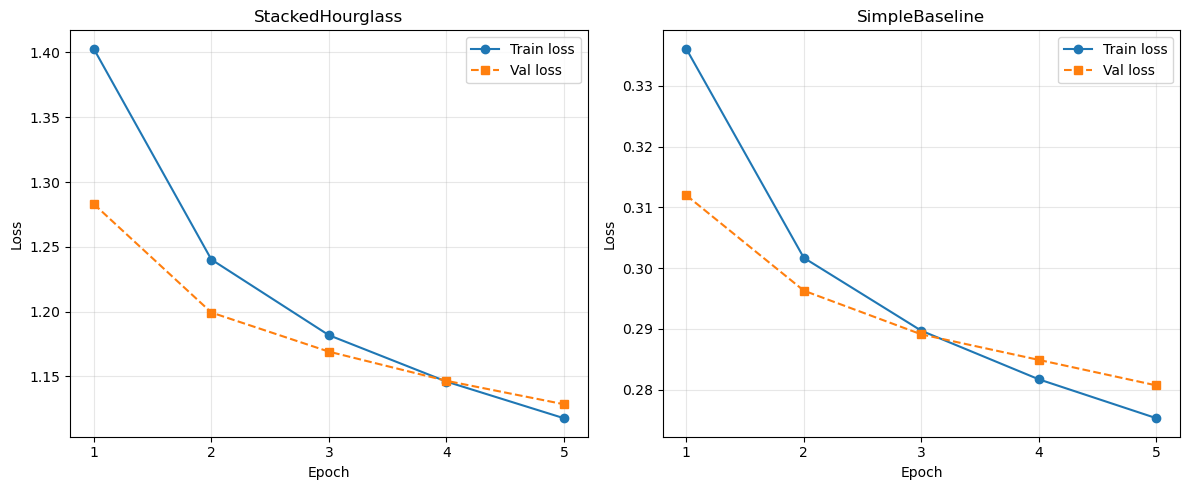

In [10]:
import matplotlib.pyplot as plt
import os

epochs = [1, 2, 3, 4, 5]

# StackedHourglass 학습 로그에서 기록한 값
hg_train = [1.4028, 1.2402, 1.1818, 1.1460, 1.1177]
hg_val   = [1.2830, 1.1993, 1.1691, 1.1466, 1.1285]

# SimpleBaseline 학습 로그에서 기록한 값
sb_train = [0.3361, 0.3017, 0.2897, 0.2817, 0.2753]
sb_val   = [0.3120, 0.2963, 0.2891, 0.2849, 0.2807]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 왼쪽: StackedHourglass
axes[0].plot(epochs, hg_train, 'o-', label='Train loss')
axes[0].plot(epochs, hg_val, 's--', label='Val loss')
axes[0].set_title('StackedHourglass')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_xticks(epochs)
axes[0].legend()
axes[0].grid(alpha=0.3)

# 오른쪽: SimpleBaseline
axes[1].plot(epochs, sb_train, 'o-', label='Train loss')
axes[1].plot(epochs, sb_val, 's--', label='Val loss')
axes[1].set_title('SimpleBaseline')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_xticks(epochs)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_PATH, 'loss_curves.png'), dpi=150)
plt.show()

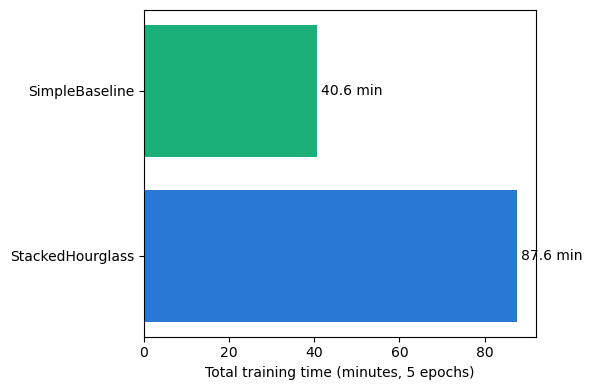

In [14]:
model_names = ['StackedHourglass', 'SimpleBaseline']
total_minutes = [87 + 37/60, 40 + 35/60]  # 1h27m37s, 40m35s

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.barh(model_names, total_minutes, color=['#2a78d6', '#1baf7a'])
ax.set_xlabel('Total training time (minutes, 5 epochs)')
for bar, val in zip(bars, total_minutes):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2, f'{val:.1f} min', va='center')
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_PATH, 'time_comparison.png'), dpi=150)
plt.show()

## 학습 곡선 (Loss Curves)

- **StackedHourglass**: train loss 1.4028 → 1.1177, val loss 1.2830 → 1.1285로 5 epoch 내내 감소. epoch 1~3까지는 val loss가 train loss보다 낮게 유지되다가, epoch 4~5에서 두 곡선이 거의 겹치며 train이 val보다 아주 살짝(약 0.01) 낮아지는 지점이 나타남. 폭이 작아 과적합 조짐의 시작?
- **SimpleBaseline**: train loss 0.3361 → 0.2753, val loss 0.3120 → 0.2807로 마찬가지로 지속 감소. epoch 3 부근에서 train과 val이 교차한 뒤, epoch 4~5에서는 train이 val보다 뚜렷하게(약 0.005) 낮아지며 격차가 벌어짐. Hourglass보다 상대적으로 더 뚜렷한 과적합 조짐..
  
- **공통점**: 두 모델 모두 학습 초반에는 val loss가 train loss보다 낮게 시작해(가벼운 augmentation 차이 등 영향) 점차 역전되는 패턴을 보였으며, 발산이나 급격한 진동 없이 전반적으로 안정적인 학습 곡선을 유지

## 학습 시간 비교

- StackedHourglass: 총 87.6분 (epoch당 약 17.5분)
- SimpleBaseline: 총 40.6분 (epoch당 약 8.1분)
- SimpleBaseline이 약 **2.2배 빠르게** 학습을 완료했다.

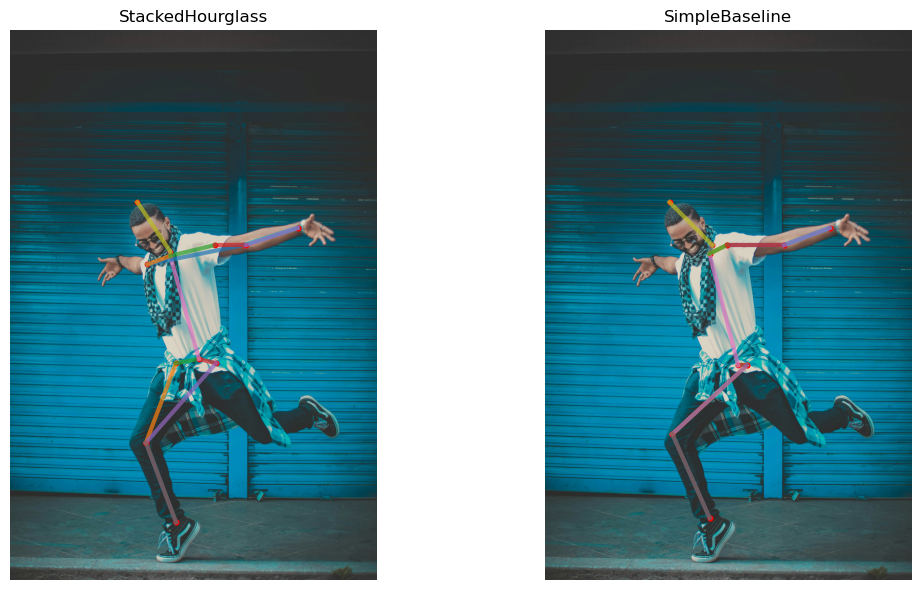

In [9]:
test_image = os.path.join(PROJECT_PATH, 'test_image.jpg')

image_hg, kp_hg = predict(model_hourglass, test_image)
image_sb, kp_sb = predict(model_simplebaseline, test_image)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
draw_skeleton_on_image(image_hg, kp_hg, title="StackedHourglass", ax=axes[0])
draw_skeleton_on_image(image_sb, kp_sb, title="SimpleBaseline", ax=axes[1])
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_PATH, 'model_comparison.png'), dpi=150)
plt.show()

## 정성적 비교 (Pose Estimation 예측 결과)

두 모델의 같은 테스트 이미지 예측 스켈레톤 비교

### 공통적으로 잘 잡은 부분
- 양팔을 벌린 자세, 머리 위치, 앞으로 뻗은 다리(오른쪽 다리) 라인은  두 모델 모두 실제 자세와 유사하게 잡아냄

### 차이점: 골반(hip) / 어깨(shoulder) keypoint 인식

- **StackedHourglass**: 좌우 고관절(L_HIP, R_HIP)과 양쪽 어깨 (L_SHOULDER, R_SHOULDER)를 각각 구분해서 검출했다. 다만 오른쪽 어깨 keypoint가 목/가슴 부위와 가까워 라인이 서로 겹쳐 보이는 경향이 있었다.
- **SimpleBaseline**: 고관절을 하나만 검출했고, 그마저도 실제로는 반대쪽(왼쪽) 다리 쪽에 연결되어 잘못된 위치에 찍혔다. 어깨도 한쪽만 찾아내 좌우 대칭 관절 쌍을 정확히 구분하는 능력이 Hourglass보다 떨어지는 것으로 보인다.

### 해석

- 짧은 학습(5 epoch)으로는 **SimpleBaseline이 좌우 대칭
  keypoint(양쪽 고관절, 양쪽 어깨)를 구분하는 학습이 아직 충분히  안 됐을 가능성**
  SimpleBaseline은 ResNet backbone이 깊은 대신 intermediate supervision이 없어서, 같은 epoch 수 대비
  세밀한 관절 구분 학습에는 Hourglass보다 더 많은 epoch이 필요
- 반면 loss 곡선상으로는 SimpleBaseline의 절대 loss 값이 더 낮게 나왔는데(0.28 vs 1.13), 이는 두 모델의 heatmap 스케일/loss 계산 방식 차이 때문일 가능성이 높고, **이번 정성적 비교 결과처럼 loss
  값만으로 실제 keypoint 정확도를 판단하기는 어렵다**
- 종합
  5 epoch 실험 기준, **StackedHourglass가 관절
  개별 인식(특히 좌우 대칭 부위) 측면에서 더 안정적인 결과**를 보였고,  SimpleBaseline은 학습 속도(약 2.2배 빠름) 면에서는 우수함

In [15]:
# 이미지 파일명 -> annotation을 빠르게 찾기 위한 lookup 딕셔너리 생성
with open(os.path.join(PROJECT_PATH, 'mpii_human_pose_v1_u12_2', 'train.json')) as f:
    all_train_annos = json.load(f)

filename_to_anno = {}
for anno in all_train_annos:
    filename_to_anno[anno['image']] = anno

print("lookup 딕셔너리 생성 완료. 총", len(filename_to_anno), "개")

def crop_person(image, anno, margin=0.3):
    # Preprocessor.crop_roi와 동일한 로직: annotation 기준으로 사람 주변만 crop
    img_width, img_height = image.size
    joints = anno['joints']
    keypoint_x = [j[0] for j in joints if j[0] > 0]
    keypoint_y = [j[1] for j in joints if j[1] > 0]

    if len(keypoint_x) == 0:
        return image  # keypoint 정보가 없으면 원본 그대로 반환

    body_height = anno['scale'] * 200.0
    extra = int(body_height * margin)

    xmin = max(int(min(keypoint_x)) - extra, 0)
    xmax = min(int(max(keypoint_x)) + extra, img_width)
    ymin = max(int(min(keypoint_y)) - extra, 0)
    ymax = min(int(max(keypoint_y)) + extra, img_height)

    return image.crop((xmin, ymin, xmax, ymax))

def predict_cropped(model, image_path, filename):
    image = Image.open(image_path).convert("RGB")
    anno = filename_to_anno.get(filename)
    if anno is not None:
        image = crop_person(image, anno)  # 학습 때처럼 사람 주변만 crop

    preprocess = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x * 2 - 1)
    ])
    inputs = preprocess(image).unsqueeze(0)
    device_ = next(model.parameters()).device
    inputs = inputs.to(device_)
    model.eval()
    with torch.no_grad():
        outputs = model(inputs)
    if not isinstance(outputs, list):
        outputs = [outputs]
    heatmap_tensor = outputs[-1].squeeze(0).permute(1, 2, 0).detach().cpu()
    kp = extract_keypoints_from_heatmap(heatmap_tensor)
    return image, kp

lookup 딕셔너리 생성 완료. 총 14679 개


In [17]:
# validation.json도 같이 불러와서 lookup에 합치기
with open(os.path.join(PROJECT_PATH, 'mpii_human_pose_v1_u12_2', 'validation.json')) as f:
    all_val_annos = json.load(f)

filename_to_anno = {}
for anno in all_train_annos:
    filename_to_anno[anno['image']] = anno
for anno in all_val_annos:
    filename_to_anno[anno['image']] = anno

print("합쳐진 lookup 딕셔너리 총 개수:", len(filename_to_anno))

# 아까 뽑은 sample_images가 실제로 lookup에 있는지 확인
for img_name in sample_images:
    print(img_name, "->", "찾음" if img_name in filename_to_anno else "❌ 못 찾음")

합쳐진 lookup 딕셔너리 총 개수: 17408
082906865.jpg -> ❌ 못 찾음
008680457.jpg -> ❌ 못 찾음
057209461.jpg -> 찾음
078529467.jpg -> 찾음


선택된 이미지: ['023325764.jpg', '001272728.jpg', '088281180.jpg', '008380416.jpg']


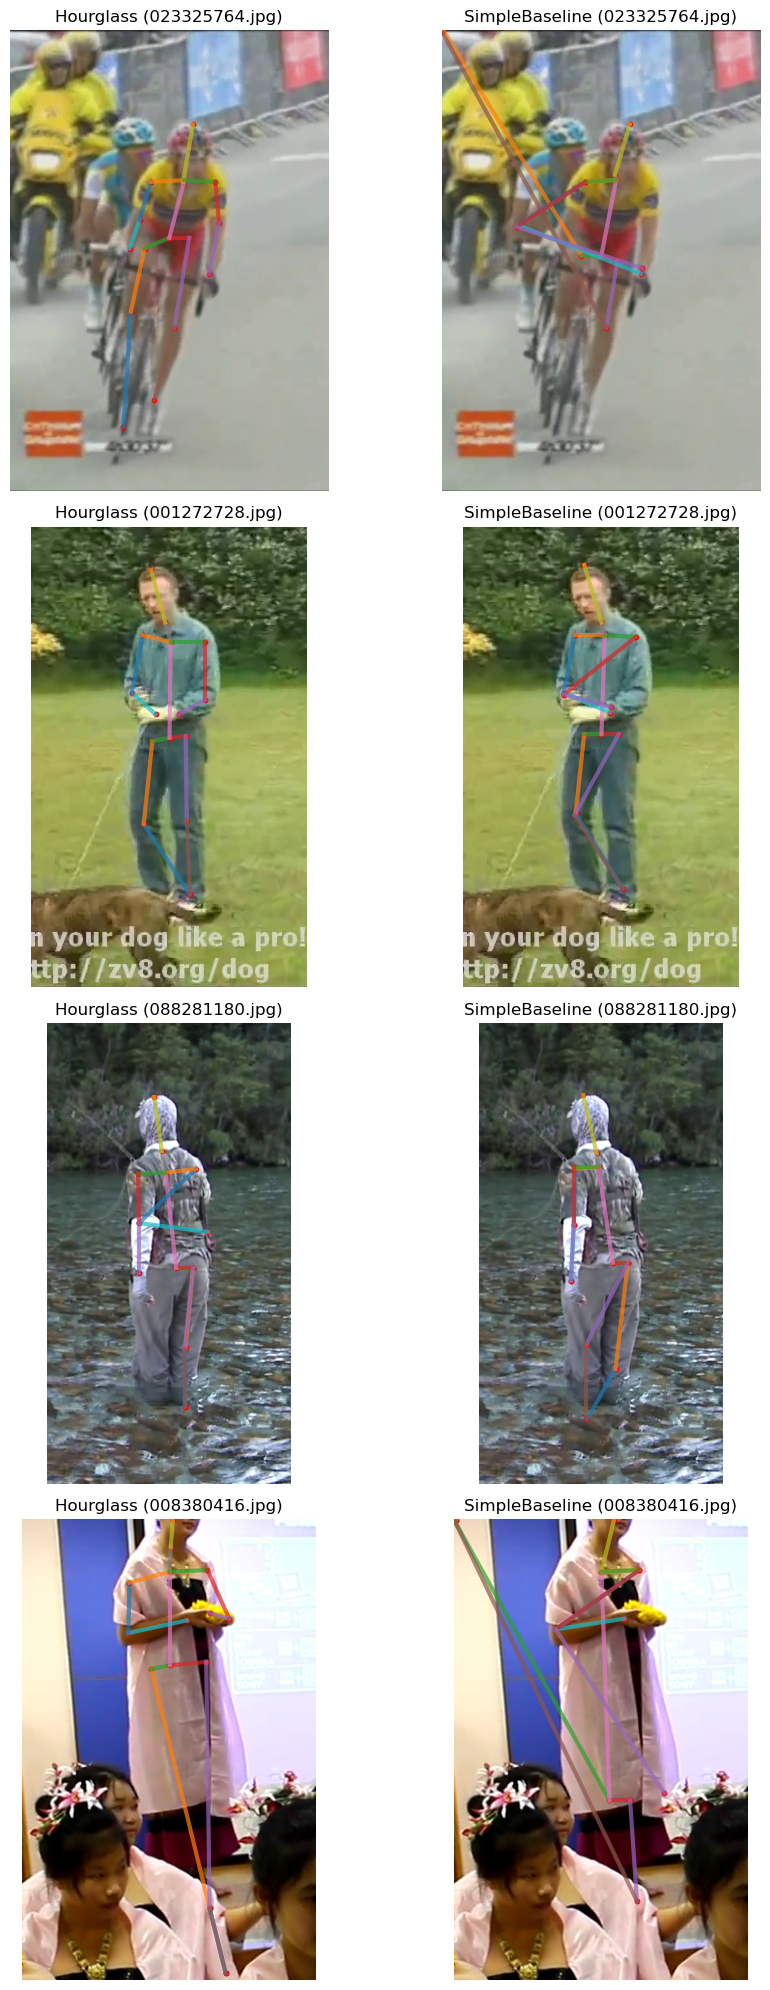

In [19]:
import random

# filename_to_anno에 있는(annotation이 확실히 존재하는) 파일명 중에서만 랜덤 샘플링
annotated_filenames = list(filename_to_anno.keys())
sample_images = random.sample(annotated_filenames, 4)
print("선택된 이미지:", sample_images)

fig, axes = plt.subplots(4, 2, figsize=(10, 20))

for i, img_name in enumerate(sample_images):
    img_path = os.path.join(IMAGE_PATH, img_name)

    image_hg, kp_hg = predict_cropped(model_hourglass, img_path, img_name)
    image_sb, kp_sb = predict_cropped(model_simplebaseline, img_path, img_name)

    draw_skeleton_on_image(image_hg, kp_hg, title=f"Hourglass ({img_name})", ax=axes[i][0])
    draw_skeleton_on_image(image_sb, kp_sb, title=f"SimpleBaseline ({img_name})", ax=axes[i][1])

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_PATH, 'more_comparisons_final.png'), dpi=150)
plt.show()

## 추가 정성적 비교 (샘플 4장)

앞서 확인된 "테스트 이미지가 annotation 없이 원본 그대로 입력되면 예측이
완전히 무너진다"는 문제를 해결(annotation 기반 crop 적용)한 뒤, MPII
train/validation 전체에서 무작위로 4장을 다시 비교함

### 사진 1 — 자전거 타는 사람 (023325764.jpg)
- **Hourglass**: 팔다리 라인이 실제 자세와 대체로 일치하며, 자전거를 잡은
  손과 다리 위치를 비교적 안정적으로 추정.
- **SimpleBaseline**: 선이 사방으로 뻗어나가며 실제 관절 위치와 거의
  무관하게 예측. 배경에 다른 사람(뒤쪽 라이더)이 겹쳐 있는 복잡한
  장면에서 두 모델의 차이가 가장 크게 드러난 사진임.

### 사진 2 — 개 목줄 들고 선 사람 (001272728.jpg)
- **Hourglass**: 몸통-팔-다리 라인이 비교적 사람 형태를 따라 자연스럽게
  이어짐.
- **SimpleBaseline**: 팔 관절 위치가 얼굴 쪽으로 잘못 튀는 등 상체 예측이
  부정확했다. 다리 쪽은 두 모델이 비슷했음.

### 사진 3 — 강가에 서 있는 뒷모습 (088281180.jpg)
- **Hourglass**: 상체(어깨-팔) 라인이 다소 꼬여 보이지만 다리는 몸에
  맞게 예측.
- **SimpleBaseline**: 반대로 상체는 비교적 단순하게 잘 잡았지만, 오른쪽
  다리 라인이 실제 다리에서 벗어남
- 두 모델 모두 완벽하지 않지만 서로 다른 부위에서 실수하는 상반된
  패턴.

### 사진 4 — 한복 입은 인물 (008380416.jpg)
- **Hourglass**: 몸통과 다리 라인이 인물 실루엣과 대체로 일치.
- **SimpleBaseline**: 상체 관절 추정이 크게 벗어나 사람 왼쪽 바깥으로 빔을 쏴버림.

### 종합 관찰
- 4장 중 **3장에서 Hourglass가 SimpleBaseline보다 안정적인 스켈레톤**을
  보여줬고, 나머지 1장(사진 3)은 각자 다른 부위에서 오차를 보였다.
- SimpleBaseline은 복잡한 배경(다른 사람, 물결무늬, 화려한 옷 패턴 등)이
  섞인 장면에서 관절이 이상한 방향으로 크게 튀는 경향이 반복적으로
  관찰되었다.
- 앞선 단일 이미지 비교에서 나타난 "SimpleBaseline이 5 epoch만으로는
  관절 위치를 세밀하게 구분하는 능력이 아직 부족하다"는 관찰과 일치하는
  패턴이며, 여러 샘플에 걸쳐 일관되게 나타난다는 것으로 생각된다.